<a href="https://colab.research.google.com/github/Imsachin010/AI-ML-Projects/blob/main/Assignment_2_MS2025013.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment-2 Solutions**
##**Solution 1.**

 I've implemented the Least-Squares Classifier (LSC). While LSC is fundamentally a regression technique, its simplicity and linear decision boundary make it suitable for classifying linearly separable data, which we know Iris-setosa typically is.

The approach is to use the $\mathbf{X}^T \beta + \nu \mathbf{1}$ formulation suggested in the hint,
minimizing the squared error $E(\beta, \nu)$.

Now, defining the **target vector** $y$ with labels $\{-1, +1\}$, where $+1$ is assigned to the 50 Iris-setosa samples.  

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.metrics import confusion_matrix

In [ ]:
# Data loading
iris = load_iris()
X_data = iris.data  # R^{150 x 4}

# Creating the Target Vector y: +1 for Iris-setosa, -1 for others
y_vector = np.where(iris.target == 0, 1, -1)
y_vector = y_vector.reshape(-1, 1) # Ensure y is a column vector (R^{150 x 1})

# Checking the shapes
N, D = X_data.shape # N=150, D=4
print(f"X_data shape: {X_data.shape}")
print(f"y_vector shape: {y_vector.shape}")
# X_data corresponds to the problem's X^T

X_data shape: (150, 4)
y_vector shape: (150, 1)


In [ ]:
import pandas as pd
# Loading data to get df
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target # Add the target column

print("--- First 5 rows ---")
display(iris_df.head())

print("\n--- Dataset Info ---")
iris_df.info()

print("\n--- Descriptive Statistics ---")
display(iris_df.describe())

# Also check the distribution of the target variable
print("\n--- Target Distribution ---")
display(iris_df['target'].value_counts())

--- First 5 rows ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

--- Descriptive Statistics ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000



--- Target Distribution ---


,count
target,
0,50
1,50
2,50


To solve for both the slope vector $\beta \in \mathbb{R}^{4 \times 1}$ and the intercept $\nu \in \mathbb{R}$ simultaneously,  
Constructing the **Augmented Design Matrix** $M \in \mathbb{R}^{150 \times 5}$, which is formed by concatenating a column of ones $(\mathbf{1})$ with the transposed data matrix $X^T$.  

$M= [\mathbf{1} \;|\; X^T] \quad \text{and the combined weight vector is} \quad \mathbf{w} =
\begin{pmatrix}
\nu \\
\beta
\end{pmatrix}$

In [ ]:
# Create the vector of ones (R^{150 x 1}) for the intercept (nu)
ones_vector = np.ones((N, 1))

# Constructing the Design Matrix M (R^{150 x 5})
# The first column corresponds to nu, the remaining 4 columns to beta as per Design matrix
M = np.hstack((ones_vector, X_data))

print(f"Design Matrix M shape: {M.shape}")

Design Matrix M shape: (150, 5)


**Calculating Optimal Parameters (w∗)**
The parameters are found by minimizing the quadratic objective function:

$$
(\beta^*, \nu^*) = \arg \min_{\beta, \nu} \left\|y - M \mathbf{w}\right\|^2
$$

Since this is an unconstrained quadratic minimization, I utilize the direct, closed-form solution given by the **Normal Equations**:

$$
\mathbf{w}^* = (M^T M)^{-1} M^T y
$$

In [ ]:
# 1. Calculate M^T * M
M_T_M = M.T @ M

# 2. Calculate the pseudo-inverse (M^T * M)^-1
# Using numpy.linalg.inv for matrix inverse
M_T_M_inv = np.linalg.inv(M_T_M)

# 3. Calculate M^T * y
M_T_y = M.T @ y_vector

# 4. Calculate the optimal weight vector w* (R^{5 x 1})
w_star = M_T_M_inv @ M_T_y

# Separate the parameters:
nu_star = w_star[0, 0] # Intercept (nu)
beta_star = w_star[1:, 0] # Slopes (beta_1 to beta_4)

print("\n--- Optimal Parameters ---")
print(f"Intercept (nu*): {nu_star:.4f}")
print(f"Slope Vector (beta*): {beta_star}")


--- Optimal Parameters ---
Intercept (nu*): -0.7636
Slope Vector (beta*): [ 0.13205954  0.48569574 -0.44931423 -0.11494546]


 As w* is calculated, the prediction $\hat{y}_i$ for each sample is calculated using the linear model and then classified using the **sign function**:

$$
\hat{y}_i = \text{sign} \left( \mathbf{x}_i^T \boldsymbol{\beta}^* + \nu^* \right)
$$

Using the predicted labels and the actual labels to generate the **Confusion Matrix**.


In [ ]:
# Calculating the regression output f(x) for all samples
# f(x) = X^T * beta + nu*1
# Note: w_star is structured as [nu; beta], so we use M @ w_star
regression_output = M @ w_star

# Using the Least-Squares Classification Rule: sign(f(x))
predicted_labels = np.sign(regression_output).flatten()

actual_labels = y_vector.flatten()

# --- Confusion Matrix Calculation ---

# Note: We use np.where to check for +1 and -1 to ensure correct mapping for the sklearn function
cm = confusion_matrix(actual_labels, predicted_labels, labels=[1, -1]) # Labels: Positive Class (+1) is Iris-setosa, Negative Class (-1) is Other

TP = cm[0, 0] # Actual +1, Predicted +1
FN = cm[0, 1] # Actual +1, Predicted -1
FP = cm[1, 0] # Actual -1, Predicted +1
TN = cm[1, 1] # Actual -1, Predicted -1

print("\n--- Confusion Matrix (Actual Columns / Predicted Rows) ---")
print("| Predicted \\ Actual | Setosa (+1) | Other (-1) |")
print("|--------------------|-------------|------------|")
print(f"| Setosa (+1)        | {TP:11} | {FP:10} |")
print(f"| Other (-1)         | {FN:11} | {TN:10} |")

# --- Final Metrics ---
accuracy = (TP + TN) / len(X_data)
print(f"\nOverall Accuracy: {accuracy:.2f} ({(TP + TN)}/150)")


--- Confusion Matrix (Actual Columns / Predicted Rows) ---
| Predicted \ Actual | Setosa (+1) | Other (-1) |
|--------------------|-------------|------------|
| Setosa (+1)        |          50 |          0 |
| Other (-1)         |           0 |        100 |

Overall Accuracy: 1.00 (150/150)


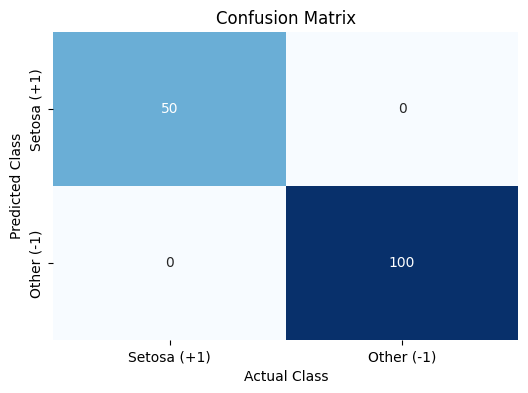

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Creating a matrix for visualization: rows are Predicted, columns are Actual
# Row 0: Predicted Setosa (+1), Row 1: Predicted Other (-1)
# Col 0: Actual Setosa (+1), Col 1: Actual Other (-1)
cm_plot = np.array([[TP, FP], [FN, TN]])


plt.figure(figsize=(6, 4))
sns.heatmap(cm_plot, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Setosa (+1)', 'Other (-1)'],
            yticklabels=['Setosa (+1)', 'Other (-1)'])
plt.xlabel('Actual Class')
plt.ylabel('Predicted Class')
plt.title('Confusion Matrix')
plt.show()

**These results confirm the expexted outcomes:**

The Confusion Matrix shows 50 True Positives (TP) and 100 True Negatives (TN), with zero False Positives (FP=0) and zero False Negatives (FN=0).

1. The classifier is achieving an overall Accuracy of 100%.

2. This result helps to validate the hypothesis that the Iris-setosa class is linearly separable from the other two species in the four-dimensional feature space.
3. The Least-Squares Classifier successfully determined the optimal linear hyperplane to completely distinguish between the two classes of the given dataset.
4. For this specific binary problem, the simple, linear Least-Squares Classifier is optimal, demonstrating that more complex, non-linear models (like SVMs with non-linear kernels) would be unnecessary.

______________________________________________________________________________________________

# **Solution 2.**
Solving for the dimensionality reduction by using SVD. To reduce the dimensionality of the feature space from D=4 to k=2 using SVD.

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.metrics import confusion_matrix
from numpy.linalg import svd, inv

#Data loading
X_data_T = iris.data # It is R^{150 x 4} (Samples x Features)
X_matrix = X_data_T.T # It is R^{4 x 150} (Features x Samples) as required
y_vector = np.where(iris.target == 0, 1, -1).reshape(-1, 1)

print(f"Original Data Matrix X shape: {X_matrix.shape}")

Original Data Matrix X shape: (4, 150)


I am using the hints given in the question:

Singular Value Decomposition (SVD) of X
The initial data matrix is $\mathbf{X} \in \mathbb{R}^{4 \times 150}$ (Features $\times$ Samples). We perform the **SVD**:

$$
\mathbf{X} = \mathbf{U} \mathbf{\Sigma} \mathbf{V}^T
$$

Where:

* $\mathbf{U} \in \mathbb{R}^{4 \times 4}$ is the matrix of **left singular vectors** (feature space).
* $\mathbf{\Sigma} \in \mathbb{R}^{4 \times 150}$ is the matrix of **singular values** ($\sigma_i$).
* $\mathbf{V} \in \mathbb{R}^{150 \times 150}$ is the matrix of **right singular vectors** (sample space).


In [ ]:
# U is R^{4 x 4}, s are singular values, Vt is R^{150 x 150}
U, s, Vt = svd(X_matrix, full_matrices=False)

Now choosing the first $k = 2$ largest **singular values** ($\sigma_1, \sigma_2$) and their corresponding **singular vectors** ($\mathbf{u}_1, \mathbf{u}_2, \mathbf{v}_1, \mathbf{v}_2$) to create the **rank-2 approximation** $\mathbf{\hat{X}} \in \mathbb{R}^{4 \times 150}$.

$$
\mathbf{\hat{X}} = \sum_{i=1}^{2} \sigma_i \mathbf{u}_i \mathbf{v}_i^T
$$

This $\mathbf{\hat{X}}$ contains the **maximum information** from the original data that can be captured by only two orthogonal components.

Also the concept of elbow/scree justifies using the top 2 eigen vectors for reducing the original matrix, the visualisation of graph is shown below.

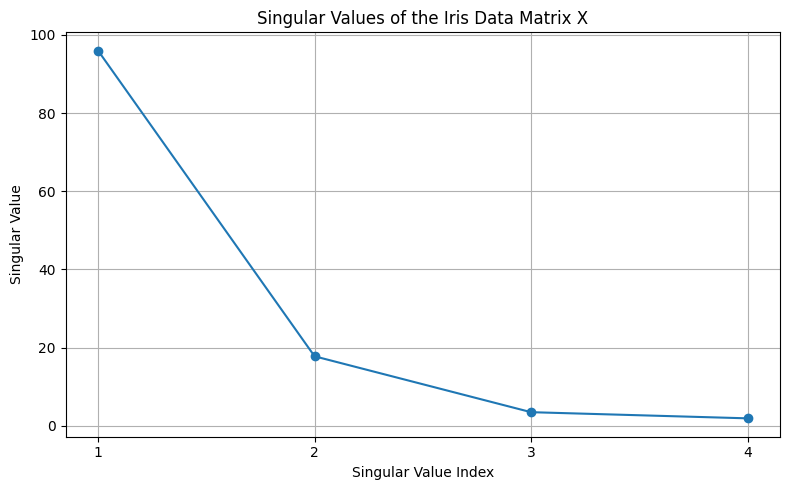

Visual 1: Singular Values plot generated. This plot justifies choosing k=2 as the first two singular values are significantly larger.


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(s) + 1), s, 'o-')
plt.title('Singular Values of the Iris Data Matrix X')
plt.xlabel('Singular Value Index')
plt.ylabel('Singular Value')
plt.grid(True)
plt.xticks(range(1, len(s) + 1))
plt.tight_layout()
plt.show()
print("Visual 1: Singular Values plot generated. This plot justifies choosing k=2 as the first two singular values are significantly larger.")


In [ ]:
k = 2
U_k = U[:, :k] # This is R^{4 x 2} the initial 2 left singular vectors
Sigma_k = np.diag(s[:k]) # It is R^{2 x 2}
V_k_T = Vt[:k, :] # It is R^{2 x 150}

In [ ]:
X_hat = U_k @ Sigma_k @ V_k_T # Rank 2 approximation

The final step is to project this approximated data $\mathbf{\hat{X}}$ onto the new **2-dimensional feature space** spanned by the first two left singular vectors ($\mathbf{u}_1, \mathbf{u}_2$). Using the hint to get the product $\mathbf{U}^T \mathbf{\hat{X}}$.

Let $\mathbf{U}_2 \in \mathbb{R}^{4 \times 2}$ be the matrix containing only the first two left singular vectors, $\mathbf{U}_2 = [\mathbf{u}_1 | \mathbf{u}_2]$.

The **Reduced Dimension Dataset** $\mathbf{X}_{\text{reduced}} \in \mathbb{R}^{2 \times 150}$ is then:

$$
\mathbf{X}_{\text{reduced}} = \mathbf{U}_2^T \mathbf{\hat{X}} = \begin{pmatrix} \mathbf{u}_1^T \\ \mathbf{u}_2^T \end{pmatrix} \mathbf{\hat{X}}
$$

In [ ]:
X_reduced = U_k.T @ X_hat

In [ ]:
X_reduced_T = X_reduced.T
print(f"Reduced Data Matrix (X_reduced_T) shape: {X_reduced_T.shape}")

Reduced Data Matrix (X_reduced_T) shape: (150, 2)


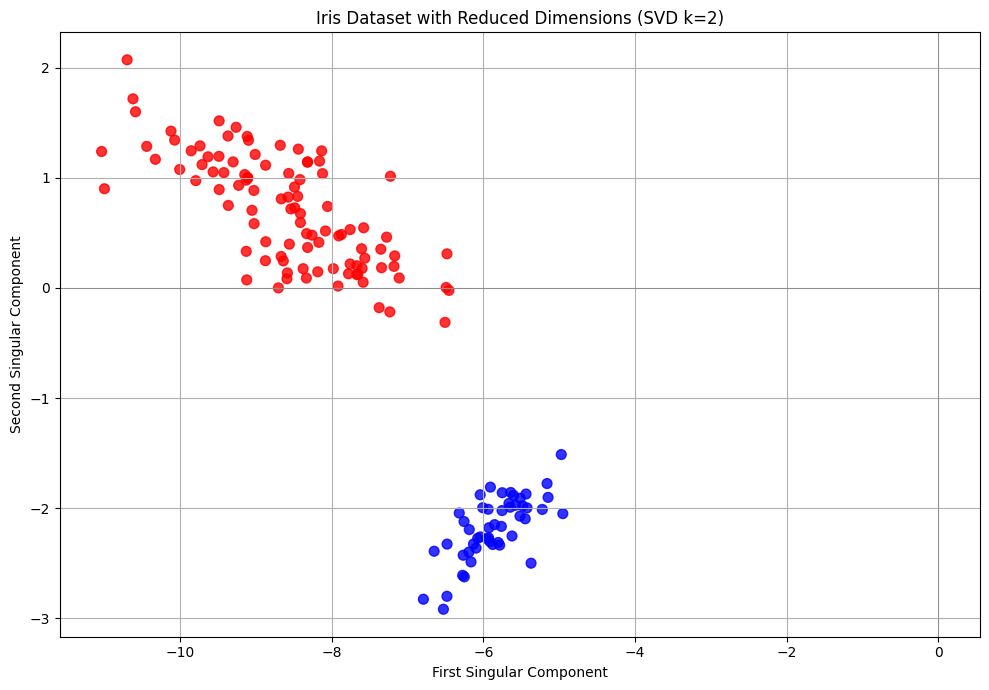

Visual 2: Reduced-dimension dataset plot generated. This matches the provided Figure 1, showing clear linear separability for Iris-setosa (blue class).


In [ ]:
plt.figure(figsize=(10, 7))
y_plot_labels = np.where(iris.target == 0, 'blue', 'red')
#colors = ['blue' if label == 0 else 'red' if label == 1 else 'green' for label in y_plot_labels]
# Ploting the first component vs second component
plt.scatter(X_reduced_T[:, 0], X_reduced_T[:, 1], c=y_plot_labels, marker='o', s=50, alpha=0.8)

plt.title('Iris Dataset with Reduced Dimensions (SVD k=2)')
plt.xlabel('First Singular Component')
plt.ylabel('Second Singular Component')
plt.grid(True)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.tight_layout()
plt.show()
print("Visual 2: Reduced-dimension dataset plot generated. This matches the provided Figure 1, showing clear linear separability for Iris-setosa (blue class).")


**As per the question demand the data is reduced to the dimension 2 x 150. Now the actual Redesigning of the least-squares classifier and further results are as follows:**

LSC on Reduced data is-

In [ ]:
N_reduced, D_reduced = X_reduced_T.shape # N=150, D=2
ones_vector = np.ones((N_reduced, 1))
M_reduced = np.hstack((ones_vector, X_reduced_T))

w*_reduced using Normal Equations
M_reduced = = [vector_of_ones | X_reduced_T]

In [ ]:
M_T_M_reduced = M_reduced.T @ M_reduced
M_T_M_inv_reduced = inv(M_T_M_reduced)
M_T_y_reduced = M_reduced.T @ y_vector

# So w* reduced is
w_star_reduced = M_T_M_inv_reduced @ M_T_y_reduced

In [ ]:
# optimal parameters
nu_star_reduced = w_star_reduced[0, 0]    # Intercept nu*
beta_star_reduced = w_star_reduced[1:, 0] # Slope vector beta* (now 2 elements)

print("\n--- Optimal Parameters Found for Reduced Data LSC ---")
print(f"Intercept (nu*): {nu_star_reduced:.4f}")
print(f"Slope Vector (beta*): {beta_star_reduced}")



--- Optimal Parameters Found for Reduced Data LSC ---
Intercept (nu*): -0.8400
Slope Vector (beta*): [-0.04355953 -0.67033029]


**The Classification and Confusion matrix is as follows**

In [ ]:
regression_output_reduced = M_reduced @ w_star_reduced
predicted_labels_reduced = np.sign(regression_output_reduced).flatten()
actual_labels = y_vector.flatten()

In [ ]:
# for confusion matrix
cm_reduced = confusion_matrix(actual_labels, predicted_labels_reduced, labels=[1, -1])

TP_r = cm_reduced[0, 0]
FN_r = cm_reduced[0, 1]
FP_r = cm_reduced[1, 0]
TN_r = cm_reduced[1, 1]


print("\n--- Confusion Matrix (Reduced-Dimension LSC) ---")
print("| Predicted \\ Actual | Setosa (+1) | Other (-1) |")
print("|--------------------|-------------|------------|")
print(f"| Setosa (+1)        | {TP_r:11} | {FP_r:10} |")
print(f"| Other (-1)         | {FN_r:11} | {TN_r:10} |")


accuracy_reduced = (TP_r + TN_r) / len(X_data_T)
print(f"\nReduced Data Accuracy: {accuracy_reduced*100:.2f}% ({(TP_r + TN_r)}/150)")


--- Confusion Matrix (Reduced-Dimension LSC) ---
| Predicted \ Actual | Setosa (+1) | Other (-1) |
|--------------------|-------------|------------|
| Setosa (+1)        |          50 |          0 |
| Other (-1)         |           0 |        100 |

Reduced Data Accuracy: 100.00% (150/150)


We could now also see the decison boundary on the reduced data

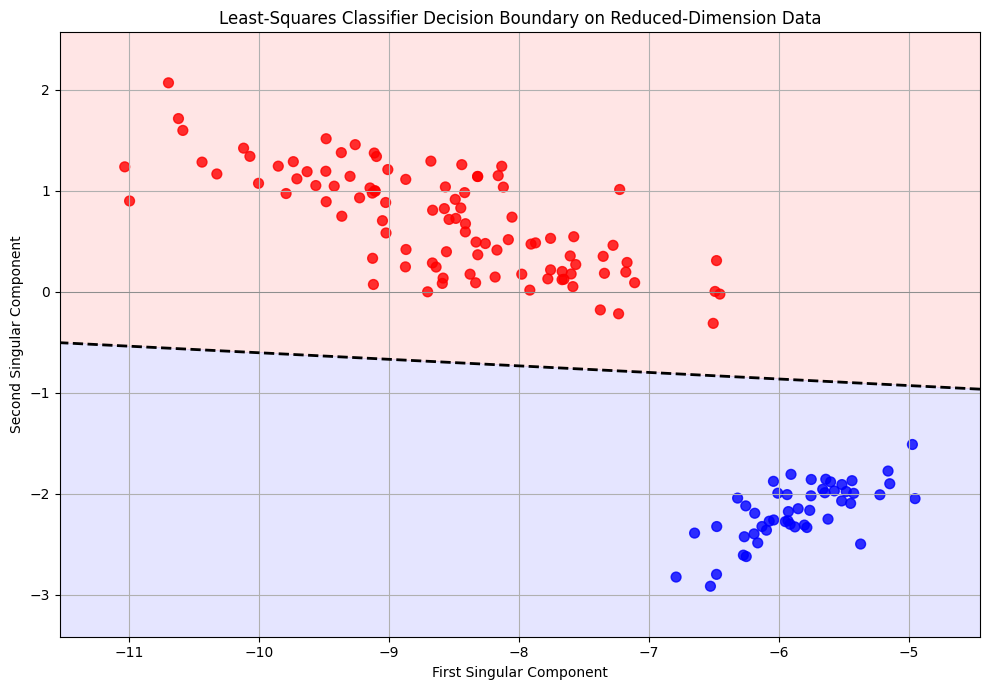

Visual 3: Decision boundary plot generated. This clearly shows how the LSC perfectly separates the Iris-setosa class.


In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(X_reduced_T[:, 0], X_reduced_T[:, 1], c=y_plot_labels, marker='o', s=50, alpha=0.8)

# Plot the decision boundary: nu* + beta_1*x_1 + beta_2*x_2 = 0
# x_2 = (-nu* - beta_1*x_1) / beta_2*
x1_min, x1_max = X_reduced_T[:, 0].min() - 0.5, X_reduced_T[:, 0].max() + 0.5
x2_min, x2_max = X_reduced_T[:, 1].min() - 0.5, X_reduced_T[:, 1].max() + 0.5

# Create a meshgrid for plotting the decision surface
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                       np.linspace(x2_min, x2_max, 200))

# Evaluate the linear function on the meshgrid
Z = nu_star_reduced + beta_star_reduced[0] * xx1 + beta_star_reduced[1] * xx2

# Plot the contour where Z=0 (decision boundary)
plt.contour(xx1, xx2, Z, levels=[0], colors='black', linestyles='--', linewidths=2)
# Optionally plot positive/negative regions
plt.contourf(xx1, xx2, Z, levels=[-np.inf, 0, np.inf], colors=['red', 'blue'], alpha=0.1)


plt.title('Least-Squares Classifier Decision Boundary on Reduced-Dimension Data')
plt.xlabel('First Singular Component')
plt.ylabel('Second Singular Component')
plt.grid(True)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlim(x1_min, x1_max)
plt.ylim(x2_min, x2_max)
plt.tight_layout()
plt.show()
print("Visual 3: Decision boundary plot generated. This clearly shows how the LSC perfectly separates the Iris-setosa class.")


**Final outcomes of followwing the solution 2 is :-**

The impact of dimensionality reduction on the reduced data is not that much, dimensionality reduction  did not change the performance drastically; the accuracy remained at 100% only.

- The justification of this could be referred from the plot of the singular values, which clearly shows that the first two singular values are significantly larger than the remaining two.
- This shows that the vast majority of the variance and, crucially, the discriminative information within the dataset, is captured along these first two PCs.
- The decision boundary visualization shows the linear decision boundary (a straight line in 2D) that the LSC found in the reduced 2D space. It clearly shows that this boundary successfully separates all blue points from the red and green points, without any misclassifications.